<a href="https://colab.research.google.com/github/san031/Machine_learning-Artificial-Intelligence-Projects/blob/main/Stats%26probML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
iris = pd.read_csv("/content/sample_data/IRIS.csv")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
iris.shape

(150, 5)

In [ ]:
iris.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

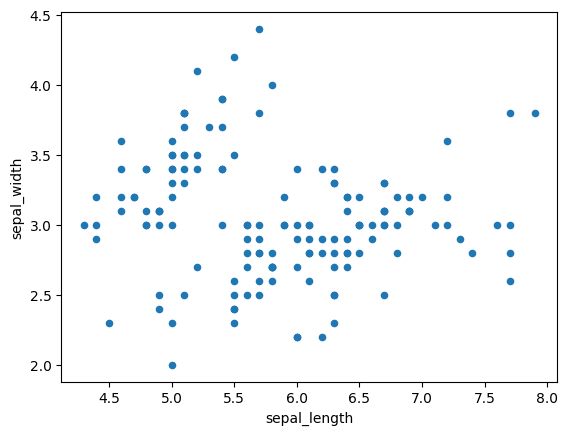

In [ ]:
iris.plot(kind = 'scatter', x = 'sepal_length', y='sepal_width')
plt.show()

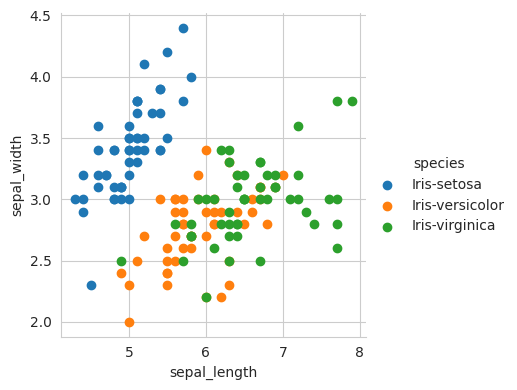

In [ ]:
sns.set_style("whitegrid")
sns.FacetGrid(iris, hue = 'species', height = 4).map(plt.scatter,"sepal_length","sepal_width").add_legend()


#### EDA (Exploratory Data Analysis)

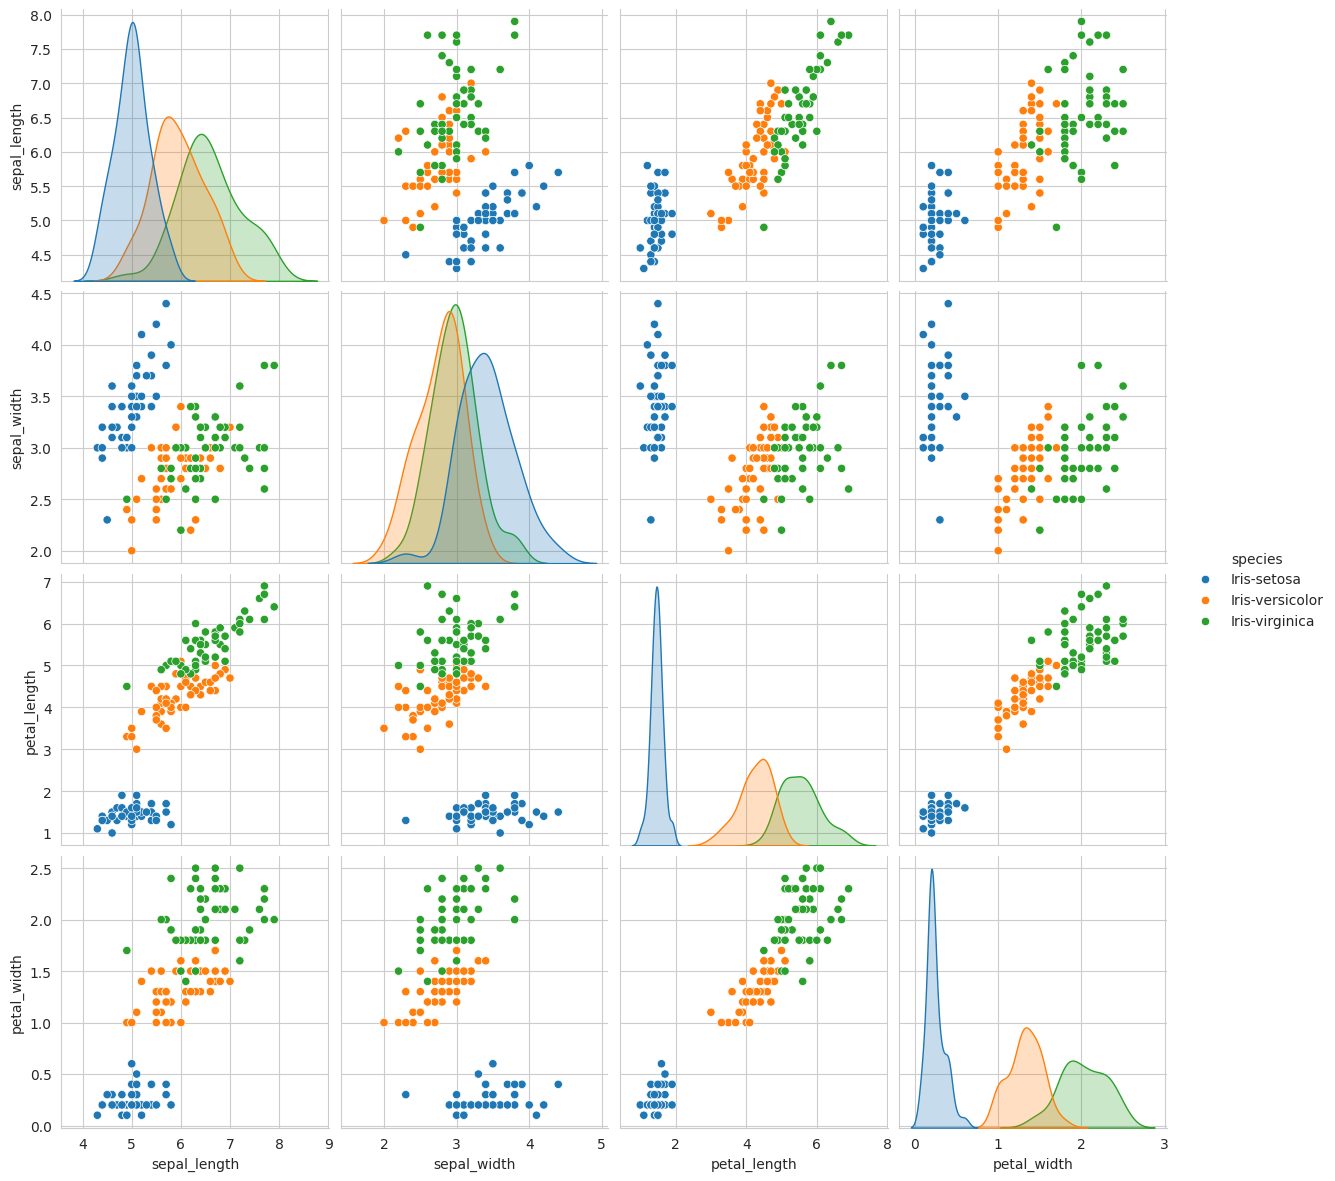

In [ ]:
sns.set_style("whitegrid")
sns.pairplot(iris, hue = 'species',height= 3)


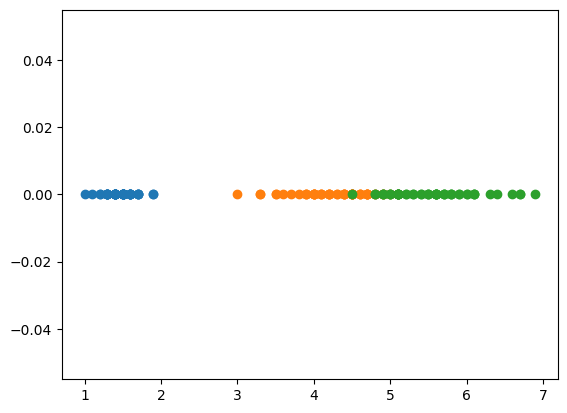

In [ ]:
iris_setosa = iris.loc[iris["species"] == "Iris-setosa"];
iris_virginica = iris.loc[iris['species'] == 'Iris-virginica'];
iris_versicolor = iris.loc[iris['species'] == 'Iris-versicolor'];
plt.plot(iris_setosa['petal_length'],np.zeros_like(iris_setosa['petal_length']),'o'),
plt.plot(iris_versicolor['petal_length'],np.zeros_like(iris_versicolor['petal_length']),'o')
plt.plot(iris_virginica['petal_length'],np.zeros_like(iris_virginica['petal_length']),'o')

plt.show();

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packa

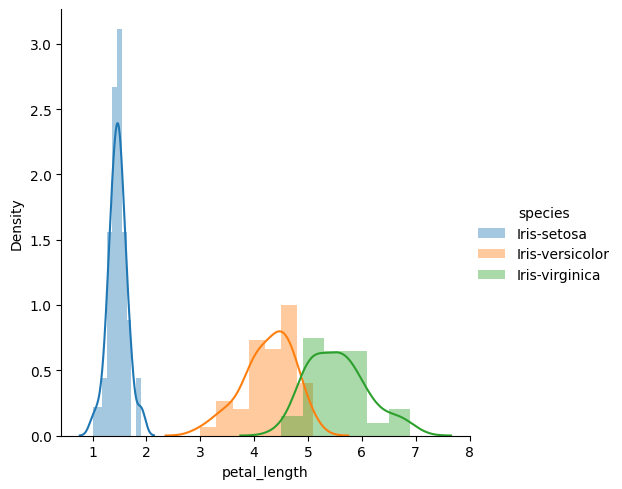

In [ ]:
sns.FacetGrid(iris, hue = 'species', height = 5).map(sns.distplot, "petal_length").add_legend();
plt.show()

In [ ]:
print("Mean")
print(np.mean(iris_setosa['petal_length']))

#mean with outlier

print(np.mean(np.append(iris_setosa["petal_length"],50)));
print(np.mean(iris_virginica["petal_length"]));


#standard deviation

print(np.std(iris_setosa['petal_length']))

print(np.std(iris_setosa['petal_length']))

Mean
1.464
2.4156862745098038
5.5520000000000005
0.17176728442867115
0.17176728442867115


[0.02 0.02 0.04 0.14 0.24 0.28 0.14 0.08 0.   0.04]
[1.   1.09 1.18 1.27 1.36 1.45 1.54 1.63 1.72 1.81 1.9 ]


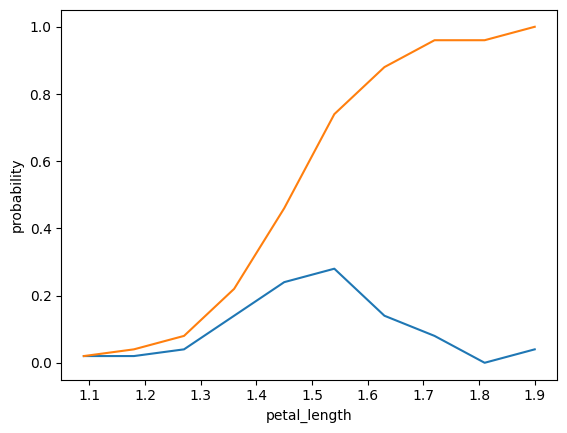

In [ ]:
counts,bin_edges = np.histogram(iris_setosa['petal_length'], bins = 10, density =True)

pdf = counts/(sum(counts))

print(pdf)
print(bin_edges)


#compute cdf

cdf = np.cumsum(pdf)
plt.plot(bin_edges[1:],pdf)
plt.plot(bin_edges[1:],cdf)
plt.xlabel("petal_length")
plt.ylabel("probability")
plt.show()

In [ ]:
### Quantiles

In [ ]:
print("\n Quantiles")
print(np.percentile(iris_setosa['petal_length'], np.arange(0,100,25)))
print(np.percentile(iris_virginica['petal_length'], np.arange(0,100,25)))
print(np.percentile(iris_versicolor['petal_length'], np.arange(0,100,25)))


 Quantiles
[1.    1.4   1.5   1.575]
[4.5   5.1   5.55  5.875]
[3.   4.   4.35 4.6 ]


In [ ]:
print("\n 90th percentiles:")
print(np.percentile(iris_setosa["petal_length"],90))
print(np.percentile(iris_virginica["petal_length"], 90))
print(np.percentile(iris_versicolor["petal_length"],90))


 90th percentiles:
1.7
6.31
4.8


## Haberman's Cancer Survival

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv('/content/sample_data/haberman.csv')
df.head()

,30,64,1,1.1
0,30,62,3,1
1,30,65,0,1
2,31,59,2,1
3,31,65,4,1
4,33,58,10,1


In [ ]:
df.columns = ["age","operation_year","auxillary_lymph_node", "survival_status"]


In [ ]:
df.head()

,age,operation_year,auxillary_lymph_node,survival_status
0,30,62,3,1
1,30,65,0,1
2,31,59,2,1
3,31,65,4,1
4,33,58,10,1


In [ ]:
df.shape

(305, 4)

In [ ]:
df.columns

Index(['age', 'operation_year', 'auxillary_lymph_node', 'survival_status'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   age                   305 non-null    int64
 1   operation_year        305 non-null    int64
 2   auxillary_lymph_node  305 non-null    int64
 3   survival_status       305 non-null    int64
dtypes: int64(4)
memory usage: 9.7 KB


In [ ]:
df['survival_status'] = df["survival_status"].map({1:'Yes',2:'No' })
df.head()

,age,operation_year,auxillary_lymph_node,survival_status
0,30,62,3,Yes
1,30,65,0,Yes
2,31,59,2,Yes
3,31,65,4,Yes
4,33,58,10,Yes


In [ ]:
df.describe()

,age,operation_year,auxillary_lymph_node
count,305.000000,305.000000,305.000000
mean,52.531148,62.849180,4.036066
std,10.744024,3.254078,7.199370
min,30.000000,58.000000,0.000000
25%,44.000000,60.000000,0.000000
50%,52.000000,63.000000,1.000000
75%,61.000000,66.000000,4.000000
max,83.000000,69.000000,52.000000


In [ ]:
df['survival_status'].value_counts()

,count
survival_status,
Yes,224
No,81


In [ ]:
status_yes = df[df['survival_status'] == 'Yes']
status_yes.describe()

,age,operation_year,auxillary_lymph_node
count,224.000000,224.000000,224.000000
mean,52.116071,62.857143,2.799107
std,10.937446,3.229231,5.882237
min,30.000000,58.000000,0.000000
25%,43.000000,60.000000,0.000000
50%,52.000000,63.000000,0.000000
75%,60.000000,66.000000,3.000000
max,77.000000,69.000000,46.000000


## Univariant Analysis

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)


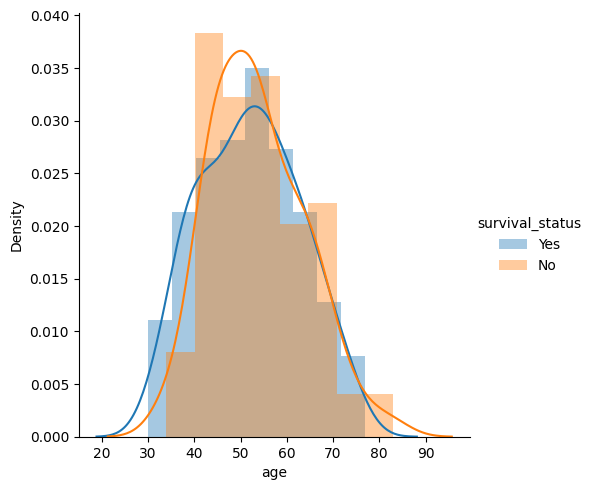

In [ ]:
sns.FacetGrid(df, hue = "survival_status", height=5).map(sns.distplot, 'age').add_legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)


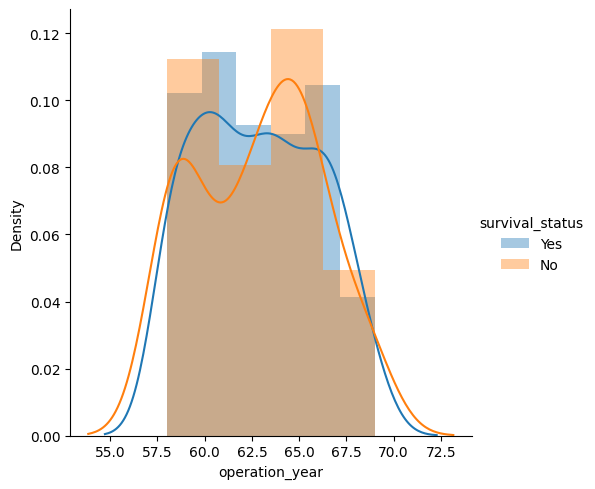

In [ ]:
sns.FacetGrid(df, hue = "survival_status", height=5).map(sns.distplot, 'operation_year').add_legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)


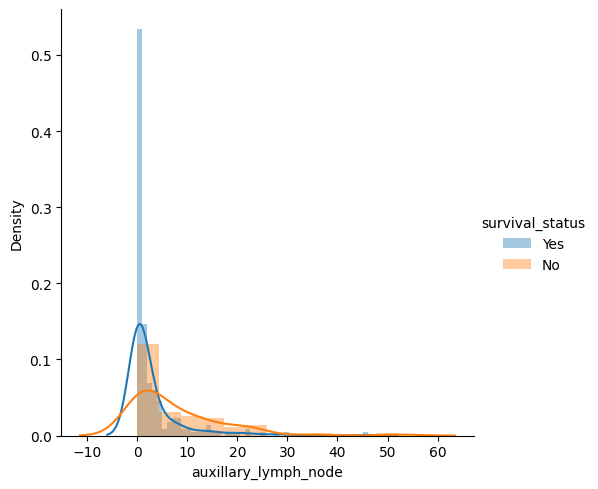

In [ ]:
sns.FacetGrid(df, hue = "survival_status", height=5).map(sns.distplot, 'auxillary_lymph_node').add_legend()
plt.show()

###CDF

In [ ]:
counts1, bin_edges1 = np.histogram(status_yes['auxillary_lymph_node'], bins = 10,density = False)

pdf1 = counts1/(sum(counts1))
print(pdf1)

cdf1 = np.cumsum(pdf1)
plt.plot(bin_edges[1:], pdf1)
plt.plot(bin_edges1[1:], cdf1, label  = 'Yes')

plt.xlabel('node')

[0.83482143 0.08035714 0.02232143 0.02678571 0.01785714 0.00446429
 0.00892857 0.         0.         0.00446429]


In [ ]:
import numpy as np
import pylab
import scipy.stats as stats

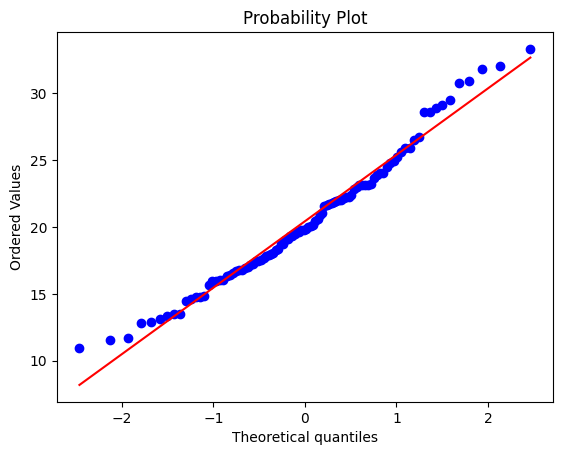

In [ ]:
measurements = np.random.normal(loc = 20, scale = 5, size = 100)
stats.probplot(measurements, dist = "norm",plot = pylab)
pylab.show()